## 1. Problem Definition

**What is the problem we are going to solve?**
A Portuguese retail bank markets *term deposits* through outbound phone calls. Across ~45k contacts, only **11.7%** of clients subscribed — meaning roughly 9 out of every 10 calls did not convert. We want to **predict, before a call is placed, which clients are likely to subscribe**, so the bank can prioritize high-probability prospects instead of dialing indiscriminately.

**Why does the problem need to be solved?**
Outbound calling is expensive: each call costs agent time and money, and low hit-rates also risk annoying uninterested customers (churn / brand fatigue). A reliable propensity model lets the bank (a) cut wasted calls, (b) raise conversion per hour of agent effort, and (c) time and target campaigns more intelligently. This is a classic, high-value marketing-analytics problem that generalizes to any direct-marketing setting.

**What aspect will a machine-learning model solve?**
The model performs **binary classification** — estimating P(subscribe) from client attributes (age, job, education, financial products held), campaign context (contact type, month, number of contacts), and prior-campaign history (`poutcome`, `pdays`, `previous`). Because the classes are imbalanced (≈7.5:1), the objective is not raw accuracy but **ranking prospects by likelihood** — we care about recall on the minority "yes" class and metrics such as ROC-AUC / PR-AUC and F1. A key design constraint, established during EDA below, is that the model must **exclude call `duration`** (a leakage variable known only *after* the call), so it remains usable for *pre-call* targeting.

## 2. Environment Setup

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'axes.titleweight': 'bold', 'font.size': 11})

NO, YES = '#4C72B0', '#DD8452'   # consistent palette: no vs yes

In [2]:

import os, io

if os.path.exists('bank-full.csv'):
    # Already in the Colab Files panel (or running locally)
    df = pd.read_csv('bank-full.csv', sep=';')
    print('Loaded bank-full.csv from the session.')
else:
    # Prompt an upload — click 'Choose Files' and pick bank-full.csv
    from google.colab import files
    uploaded = files.upload()
    fname = next(iter(uploaded))                       # whatever file you picked
    df = pd.read_csv(io.BytesIO(uploaded[fname]), sep=';')
    print('Uploaded and loaded:', fname)

print('Shape:', df.shape)
df.head()

Saving bank-full.csv to bank-full.csv
Uploaded and loaded: bank-full.csv
Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
# Types and non-null counts
df.info()

print('\nExact duplicate rows:', df.duplicated().sum())
print('Null (NaN) cells per column:')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB

Exact duplicate rows: 0
Null (NaN) cells per column:
age          0
job          0
marital      0


In [4]:
# Separate columns by type for the rest of the analysis
numeric_cols     = ['age','balance','day','duration','campaign','pdays','previous']
categorical_cols = ['job','marital','education','default','housing','loan','contact','month','poutcome']
target = 'y'

# Numeric five-number summary
df[numeric_cols].describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.9,10.6,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.3,3044.8,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.8,8.3,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.2,257.5,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.8,3.1,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.2,100.1,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.6,2.3,0.0,0.0,0.0,0.0,275.0


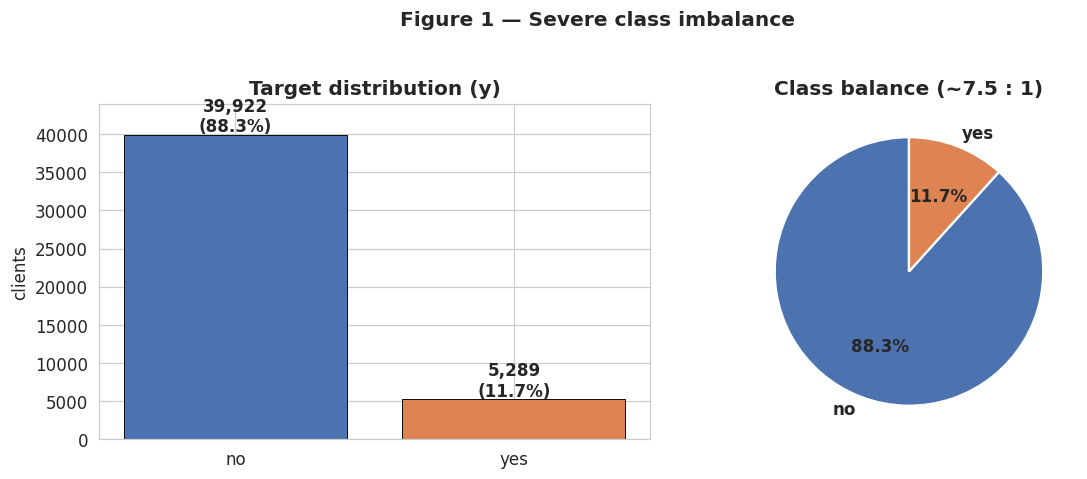

Baseline "yes" rate = 11.7%  ->  a naive "always predict no" model would be 88.3% accurate.


In [5]:
df['y_binary'] = (df['y'] == 'yes').astype(int)   # helper for rate calculations
base_rate = df['y_binary'].mean() * 100

vc = df['y'].value_counts()
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].bar(vc.index, vc.values, color=[NO, YES], edgecolor='black', lw=.6)
for i, v in enumerate(vc.values):
    ax[0].text(i, v + 400, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
ax[0].set_title('Target distribution (y)'); ax[0].set_ylabel('clients'); ax[0].set_ylim(0, 44000)
ax[1].pie(vc.values, labels=['no','yes'], colors=[NO, YES], autopct='%1.1f%%', startangle=90,
          wedgeprops=dict(edgecolor='white', lw=1.5), textprops={'fontweight':'bold'})
ax[1].set_title('Class balance (~7.5 : 1)')
plt.suptitle('Figure 1 — Severe class imbalance', fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()

print(f'Baseline "yes" rate = {base_rate:.1f}%  ->  a naive "always predict no" model would be {100-base_rate:.1f}% accurate.')

**Takeaway.** Only **11.7%** of clients subscribed. Accuracy is therefore a misleading metric (predicting "no" for everyone scores ~88%). Modeling will report **ROC-AUC, PR-AUC, recall, and F1 on the minority class**, and we will consider **class weights or resampling (e.g., SMOTE)** on the *training* fold only.

In [6]:
# 'unknown' share per categorical + the pdays sentinel
missing = {c: (df[c] == 'unknown').mean()*100 for c in categorical_cols if (df[c]=='unknown').any()}
missing['pdays == -1'] = (df['pdays'] == -1).mean()*100
miss_s = pd.Series(missing).sort_values(ascending=False)
print('Hidden-missingness (% of rows):')
print(miss_s.round(1).to_string())

# Are the "never previously contacted" signals consistent?
print('\nConsistency check (should describe the same clients):')
print('  pdays == -1        :', (df['pdays']==-1).sum())
print('  poutcome==unknown  :', (df['poutcome']=='unknown').sum())
print('  previous == 0      :', (df['previous']==0).sum())

Hidden-missingness (% of rows):
poutcome       81.7
pdays == -1    81.7
contact        28.8
education       4.1
job             0.6

Consistency check (should describe the same clients):
  pdays == -1        : 36954
  poutcome==unknown  : 36959
  previous == 0      : 36954


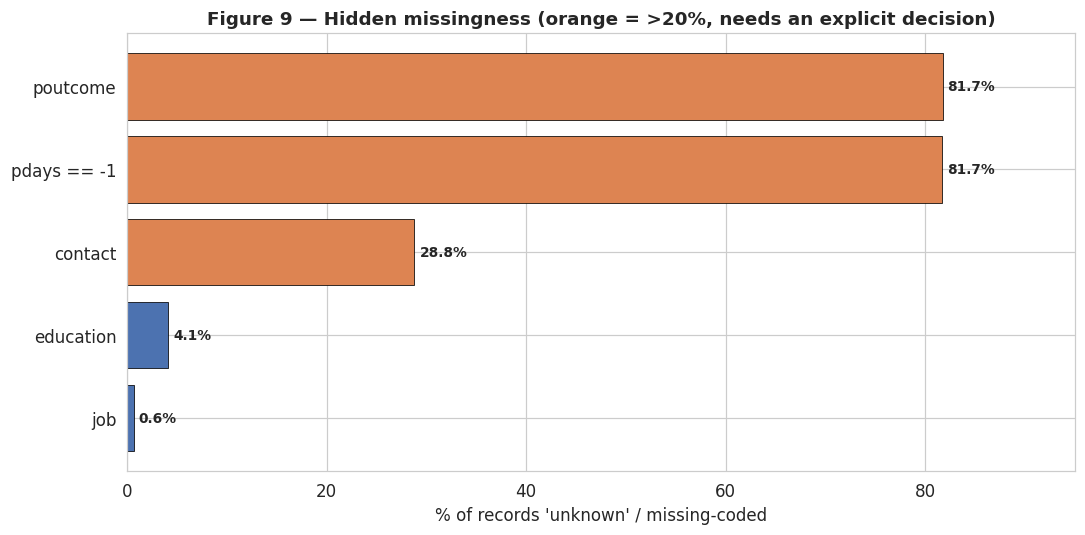

In [7]:
# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
s = miss_s.sort_values()
colors = [YES if v > 20 else NO for v in s.values]
ax.barh(s.index, s.values, color=colors, edgecolor='black', lw=.5)
for i, v in enumerate(s.values):
    ax.text(v + .5, i, f'{v:.1f}%', va='center', fontweight='bold', fontsize=9)
ax.set_xlabel("% of records 'unknown' / missing-coded"); ax.set_xlim(0, 95)
ax.set_title("Figure 9 — Hidden missingness (orange = >20%, needs an explicit decision)", fontsize=12)
plt.tight_layout(); plt.show()

**Interpretation & decisions.**
- `poutcome` is **81.7% "unknown"**, and `pdays = -1`, `poutcome = unknown`, and `previous = 0` describe **the same ~36,954 clients** — people with **no prior campaign history**. This is *structural*, not random, missingness. We will **keep "unknown" as its own category** for `poutcome`/`contact` (it is informative — see Section 7) and engineer an explicit `was_previously_contacted` flag rather than impute.
- `education` (4.1%) and `job` (0.6%) unknowns are small; we retain "unknown" as a level (tree models handle it natively; for linear models it becomes one one-hot column).
- We will **not drop rows** — the missingness carries signal and dropping would discard 80%+ of the data.

## 6. Univariate EDA — Numeric Distributions

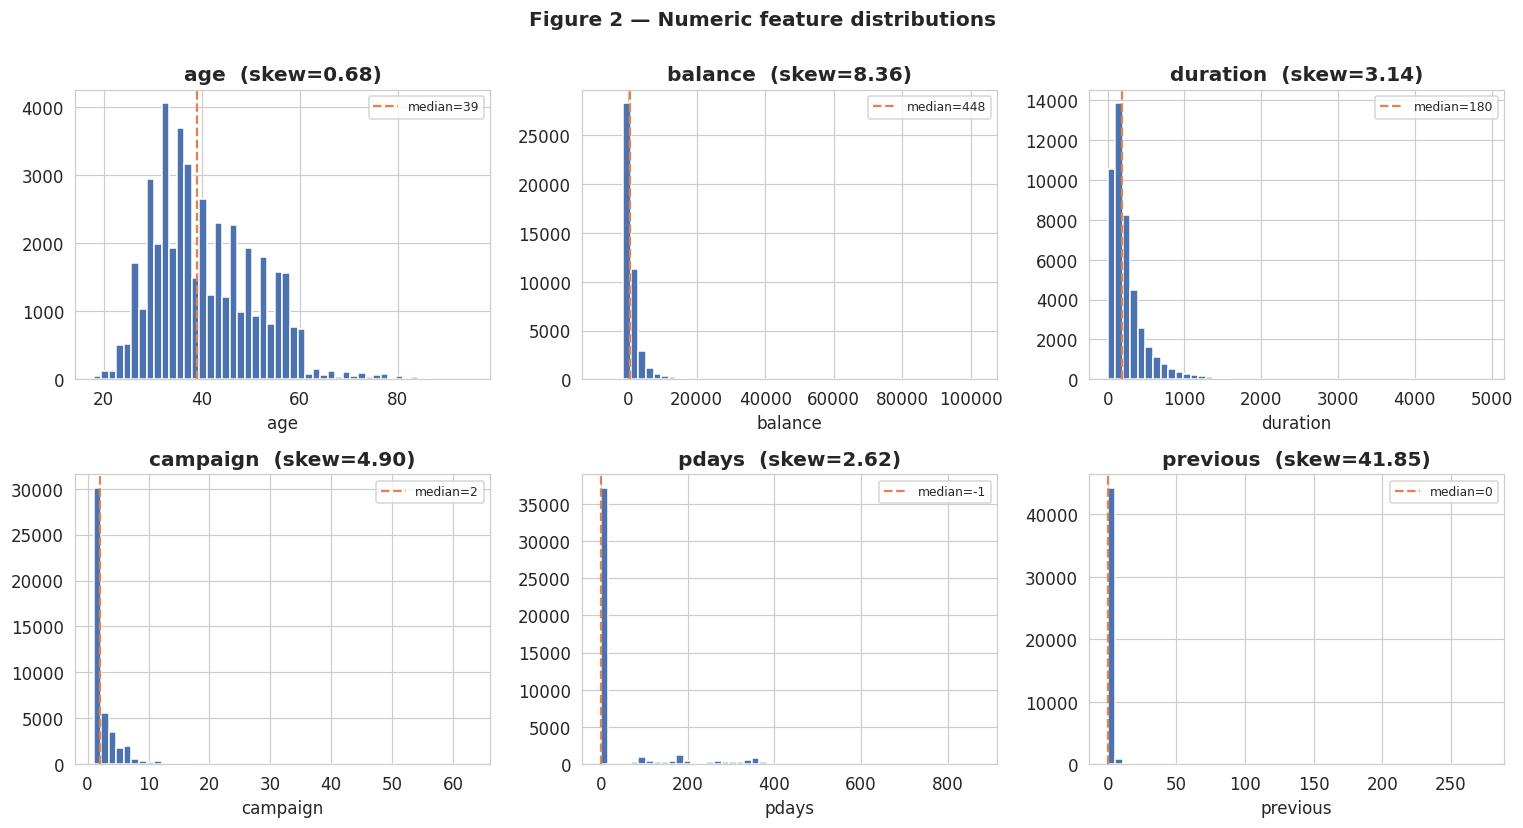

age          0.68
balance      8.36
duration     3.14
campaign     4.90
pdays        2.62
previous    41.85


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
for ax, c in zip(axes.ravel(), ['age','balance','duration','campaign','pdays','previous']):
    ax.hist(df[c], bins=50, color=NO, edgecolor='white', lw=.3)
    ax.axvline(df[c].median(), color=YES, ls='--', lw=1.5, label=f'median={df[c].median():.0f}')
    ax.set_title(f'{c}  (skew={df[c].skew():.2f})'); ax.set_xlabel(c); ax.legend(fontsize=8)
plt.suptitle('Figure 2 — Numeric feature distributions', fontweight='bold', y=1.0)
plt.tight_layout(); plt.show()

print(df[['age','balance','duration','campaign','pdays','previous']].skew().round(2).to_string())

**Takeaway.** `balance` (skew 8.4), `previous` (41.9), `campaign` (4.9) and `duration` (3.1) are **heavily right-skewed** with long tails; `age` is mildly skewed. Skew this severe hurts distance- and gradient-based models, so we will **log/`log1p`-transform** the worst offenders (and/or rely on tree ensembles, which are scale-invariant). `balance` also contains **negative values** (overdrafts) — legitimate, so a signed transform (e.g., `sign·log1p(|x|)`) is appropriate.

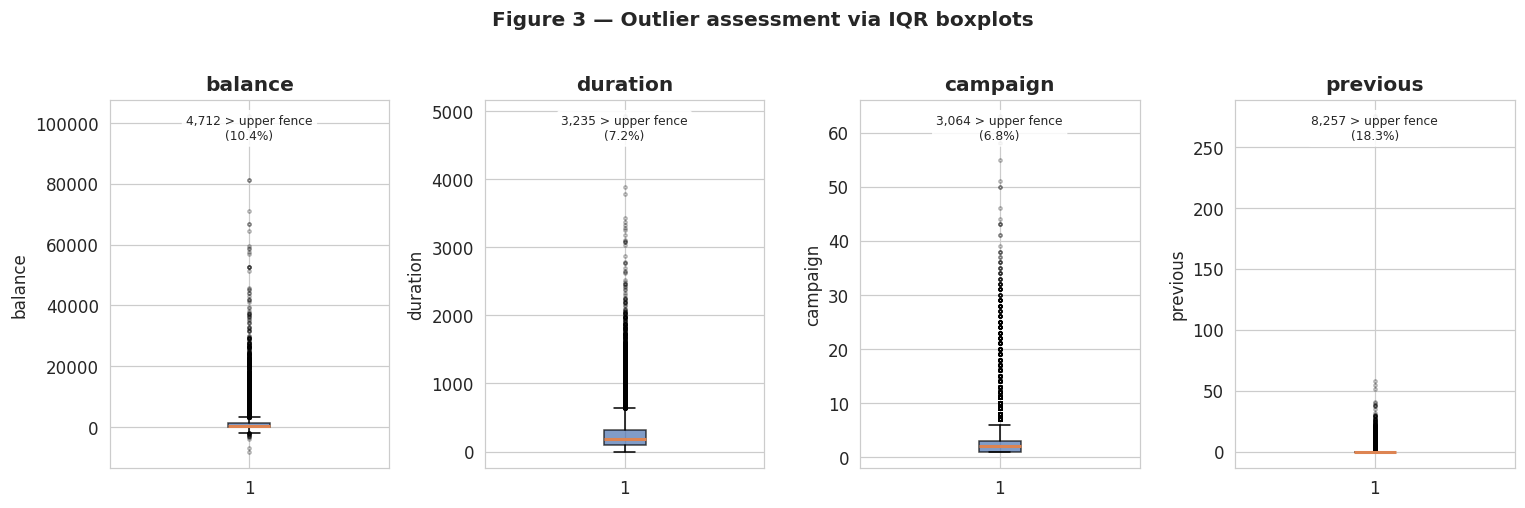

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4.5))
for ax, c in zip(axes, ['balance','duration','campaign','previous']):
    ax.boxplot(df[c], patch_artist=True, boxprops=dict(facecolor=NO, alpha=.7),
               medianprops=dict(color=YES, lw=2), flierprops=dict(marker='o', markersize=2, alpha=.3))
    q1, q3 = df[c].quantile([.25, .75]); iqr = q3 - q1; ub = q3 + 1.5*iqr
    n_out = (df[c] > ub).sum()
    ax.set_title(c); ax.set_ylabel(c)
    ax.text(0.5, 0.96, f'{n_out:,} > upper fence\n({n_out/len(df)*100:.1f}%)', transform=ax.transAxes,
            ha='center', va='top', fontsize=8, bbox=dict(boxstyle='round', fc='white', alpha=.85))
plt.suptitle('Figure 3 — Outlier assessment via IQR boxplots', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

**Interpretation & decision.** The upper tails are **domain-valid**, not data-entry errors: some clients genuinely hold large balances, a few were contacted dozens of times (`campaign` up to 63), and durations run up to 82 minutes. Because these reflect real behavior — and the rare "yes" cases often live in the tails — we do **not delete outliers**. Instead we (a) **cap/winsorize** extreme campaign counts to reduce leverage, and (b) apply the **log transforms** from Section 6, which naturally compress tails while preserving order.

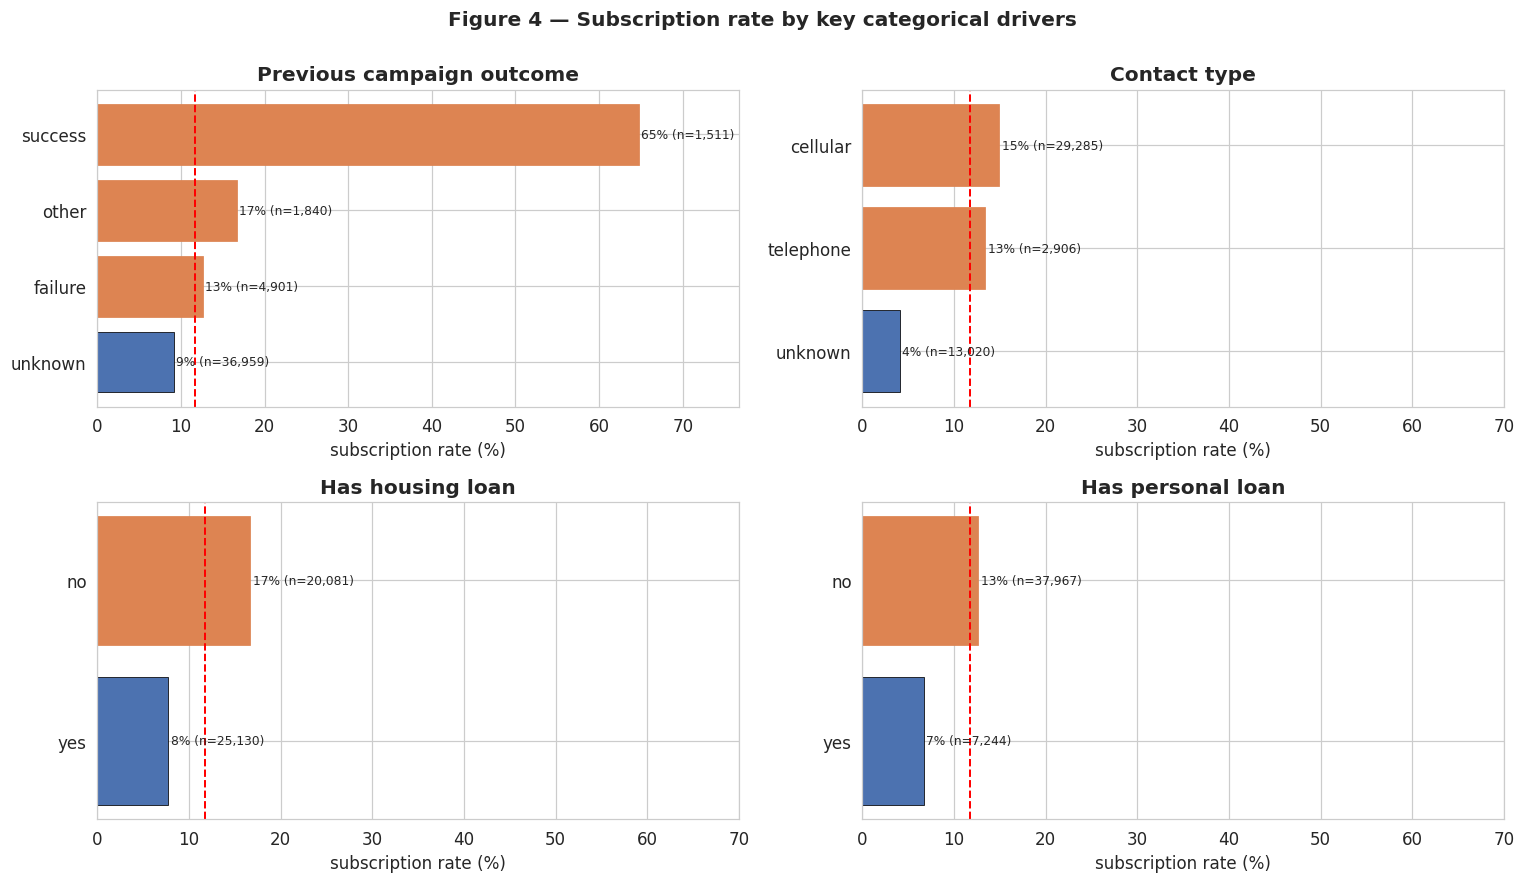

In [10]:
def rate_plot(ax, col, order=None, title=None):
    t = df.groupby(col)['y_binary'].agg(['mean','count'])
    t = t.reindex(order) if order else t.sort_values('mean')
    bars = ax.barh(t.index.astype(str), t['mean']*100, color=NO, edgecolor='black', lw=.5)
    for b, (_, r) in zip(bars, t.iterrows()):
        if r['mean']*100 > base_rate: b.set_color(YES)
        ax.text(r['mean']*100 + .3, b.get_y()+b.get_height()/2,
                f"{r['mean']*100:.0f}% (n={int(r['count']):,})", va='center', fontsize=8)
    ax.axvline(base_rate, color='red', ls='--', lw=1.3)
    ax.set_title(title or col); ax.set_xlabel('subscription rate (%)')
    ax.set_xlim(0, max(70, t['mean'].max()*100 + 12))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
rate_plot(axes[0,0], 'poutcome', title='Previous campaign outcome')
rate_plot(axes[0,1], 'contact',  title='Contact type')
rate_plot(axes[1,0], 'housing',  title='Has housing loan')
rate_plot(axes[1,1], 'loan',     title='Has personal loan')
plt.suptitle('Figure 4 — Subscription rate by key categorical drivers', fontweight='bold', y=1.0)
plt.tight_layout(); plt.show()

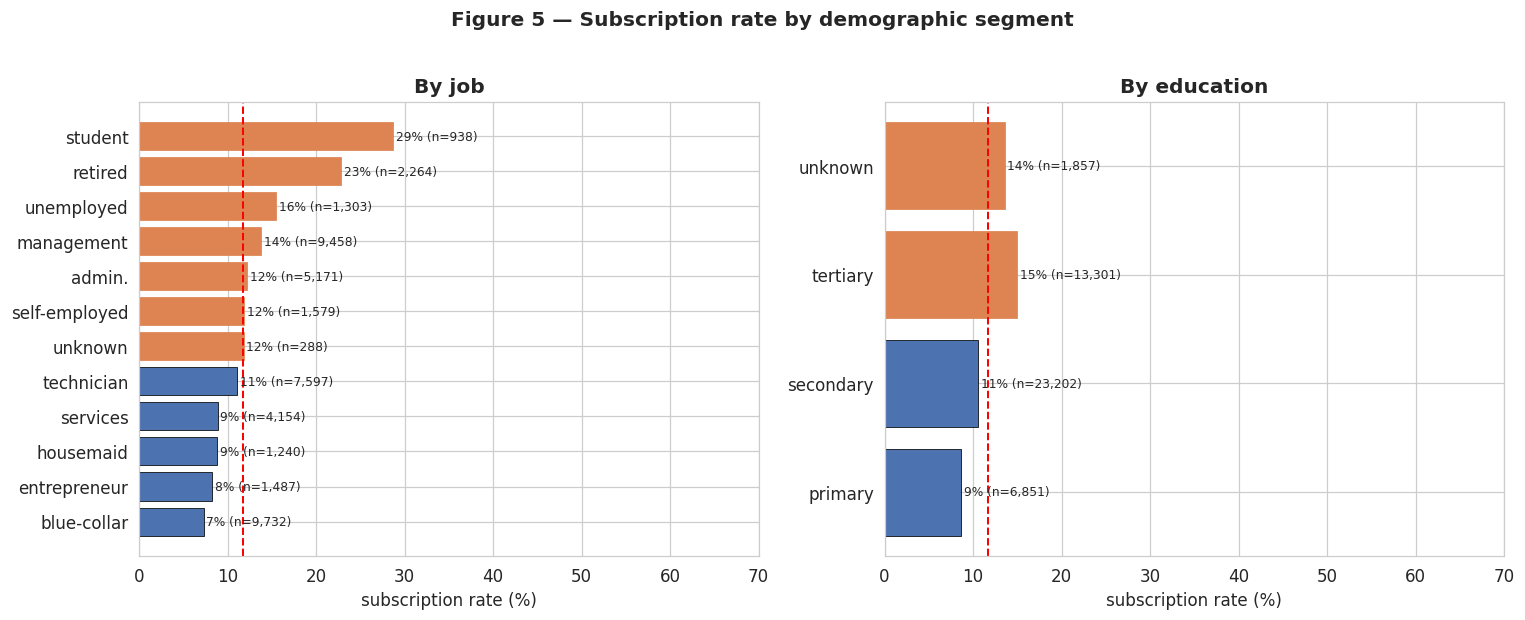

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
rate_plot(axes[0], 'job', title='By job')
rate_plot(axes[1], 'education', order=['primary','secondary','tertiary','unknown'], title='By education')
plt.suptitle('Figure 5 — Subscription rate by demographic segment', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

**Takeaways.**
- **Prior success is the single best categorical signal:** clients whose previous campaign succeeded subscribe **64.7%** of the time (vs 11.7% overall) — strong argument for keeping `poutcome`.
- **Contact type matters:** `"unknown"` contact converts at only **4.1%** (largely older records with no cellular/telephone info), vs **14.9%** for cellular.
- **Fewer obligations, higher uptake:** clients *without* a housing loan (16.7%) or personal loan (12.7%) subscribe more — plausibly they have more free cash.
- **Life stage:** **students (28.7%)** and **retirees (22.8%)** convert far above average; **blue-collar (7.3%)** lowest. **Tertiary education** outperforms primary.

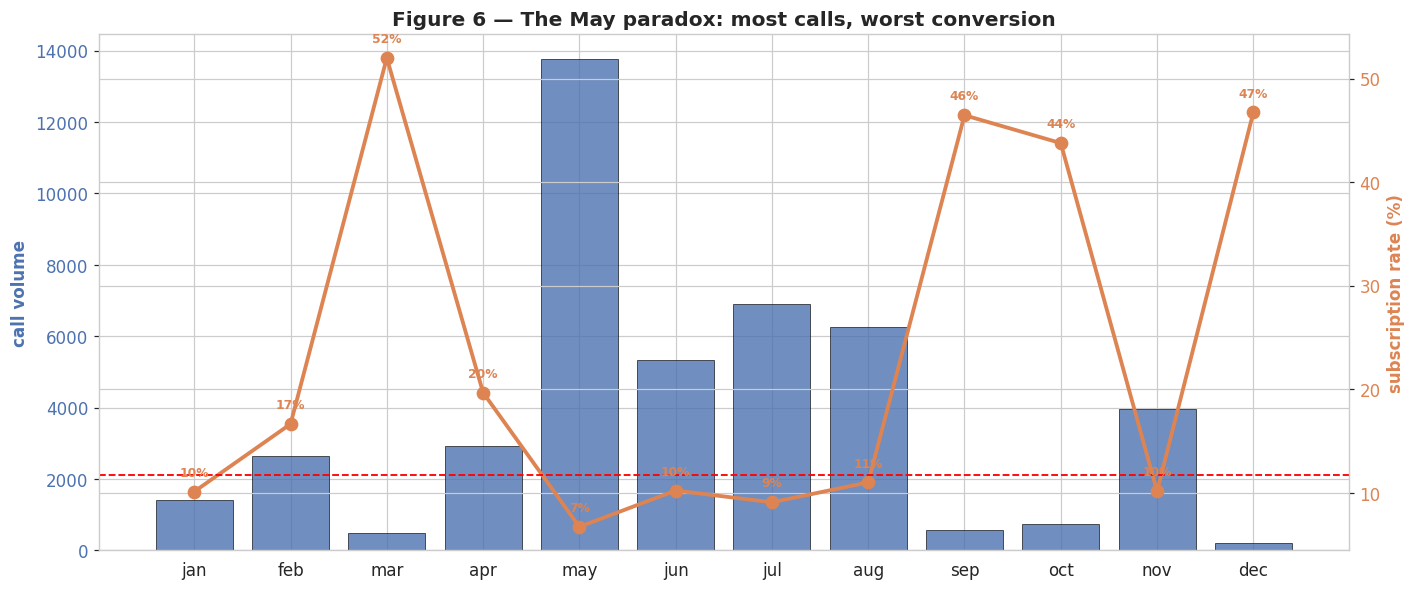

In [12]:
# The month paradox: volume vs conversion
order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
t = df.groupby('month')['y_binary'].agg(['mean','count']).reindex(order)

fig, ax1 = plt.subplots(figsize=(13, 5.5))
ax1.bar(order, t['count'], color=NO, alpha=.8, edgecolor='black', lw=.5)
ax1.set_ylabel('call volume', color=NO, fontweight='bold'); ax1.tick_params(axis='y', labelcolor=NO)
ax2 = ax1.twinx()
ax2.plot(order, t['mean']*100, color=YES, marker='o', lw=2.5, ms=8)
ax2.axhline(base_rate, color='red', ls='--', lw=1.2)
ax2.set_ylabel('subscription rate (%)', color=YES, fontweight='bold'); ax2.tick_params(axis='y', labelcolor=YES)
for m, v in zip(order, t['mean']*100):
    ax2.text(m, v + 1.5, f'{v:.0f}%', ha='center', color=YES, fontsize=8, fontweight='bold')
ax1.set_title('Figure 6 — The May paradox: most calls, worst conversion', fontweight='bold')
plt.tight_layout(); plt.show()

**Takeaway (a great "story" finding for the presentation).** **May received the most calls (13,766) yet had the *lowest* conversion (6.7%)**, while high-yield months — **Mar (52%), Sep/Dec (~47%), Oct (44%)** — were barely used. Effort and opportunity are **misaligned**, which is exactly the kind of inefficiency a targeting model plus better timing can fix. We will engineer a coarse **season / high-vs-low-month** feature.

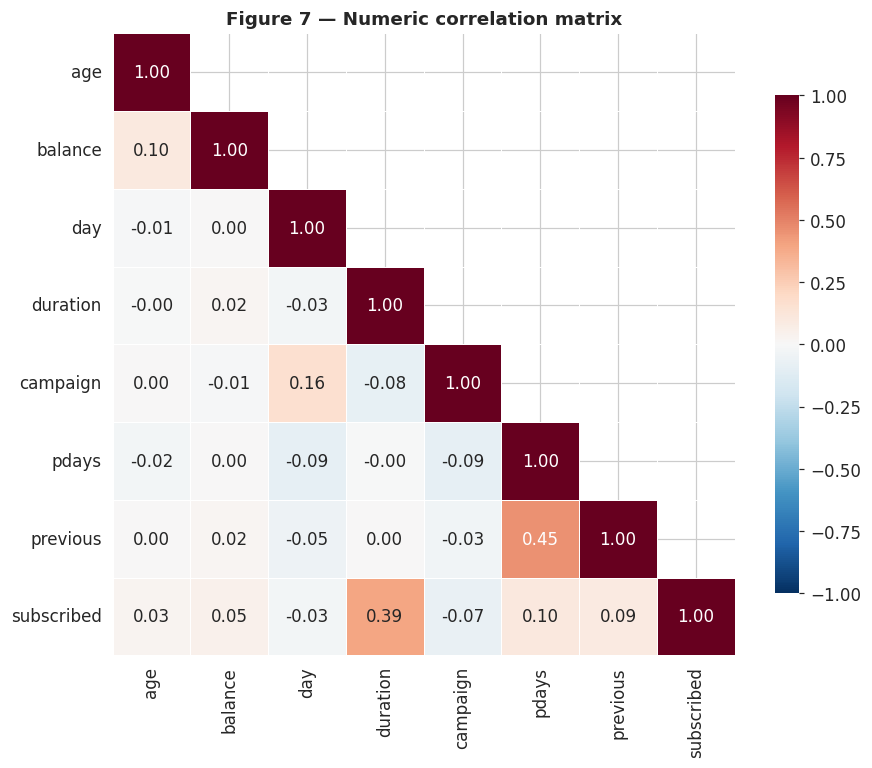

In [13]:
# Numeric correlation matrix (includes the binary target)
corr = df[numeric_cols + ['y_binary']].rename(columns={'y_binary':'subscribed'}).corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=.5, cbar_kws={'shrink':.8}, ax=ax)
ax.set_title('Figure 7 — Numeric correlation matrix', fontsize=12)
plt.tight_layout(); plt.show()

**Takeaways.**
- **`duration` (0.39)** dwarfs every other numeric correlation with the target — the leakage flag we investigate next.
- All other numeric features are **weakly correlated** with `y` (|r| ≤ 0.10), confirming the signal lives mostly in the **categorical** fields and in interactions — so non-linear models (tree ensembles) are likely to win.
- **`pdays`–`previous` (0.45)** is the only notable multicollinearity; we keep one primary signal plus the engineered contact flag to avoid redundancy.

## 9. The `duration` Leakage — A Critical Modeling Constraint

`duration` = length of the call in seconds. It is the strongest predictor, but it is **only known *after* the call has happened** (if you haven't called yet, you can't know how long the call will be — and a call of length 0 is by definition a "no"). Including it would **leak the outcome** and produce a model that looks great offline but is **useless for pre-call targeting**. The UCI dataset documentation explicitly recommends discarding it for any realistic predictive benchmark.

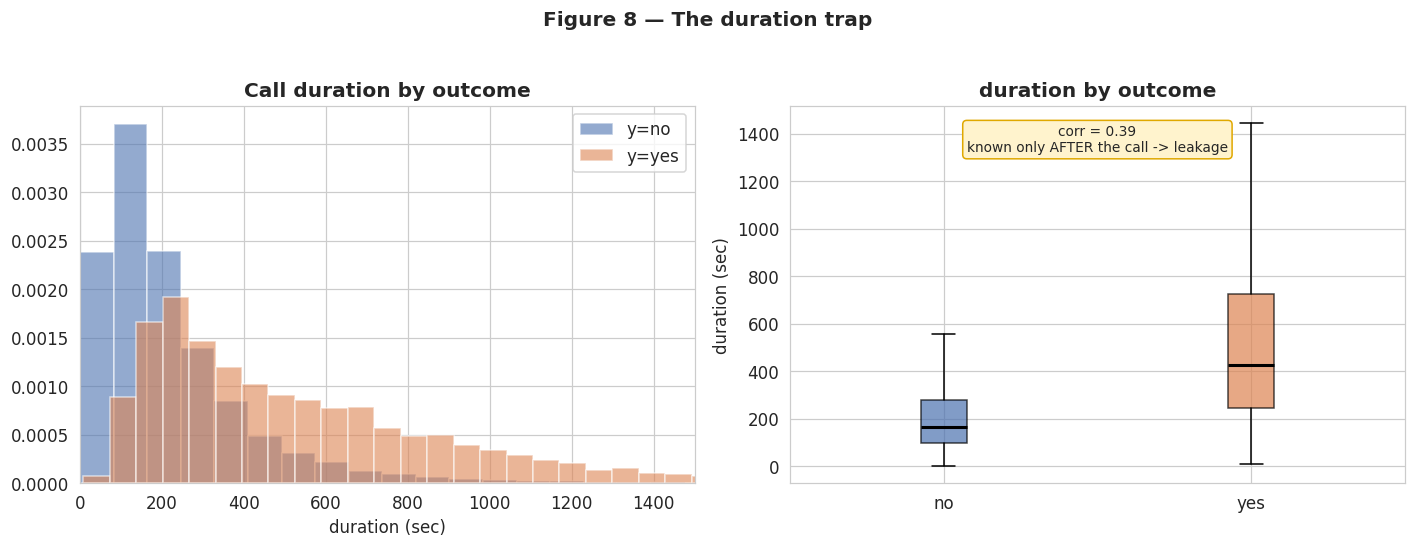

Decision: DROP `duration` from the modeling feature set.


In [14]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
for lab, c in [('no', NO), ('yes', YES)]:
    ax[0].hist(df.loc[df.y==lab, 'duration'], bins=60, alpha=.6, color=c, density=True, label=f'y={lab}')
ax[0].set_xlim(0, 1500); ax[0].set_title('Call duration by outcome'); ax[0].set_xlabel('duration (sec)'); ax[0].legend()

data = [df.loc[df.y=='no','duration'], df.loc[df.y=='yes','duration']]
bp = ax[1].boxplot(data, tick_labels=['no','yes'], patch_artist=True, showfliers=False,
                   medianprops=dict(color='black', lw=2))
for patch, c in zip(bp['boxes'], [NO, YES]): patch.set_facecolor(c); patch.set_alpha(.7)
ax[1].set_title('duration by outcome'); ax[1].set_ylabel('duration (sec)')
ax[1].text(0.5, 0.95, f"corr = {df['duration'].corr(df['y_binary']):.2f}\nknown only AFTER the call -> leakage",
           transform=ax[1].transAxes, ha='center', va='top', fontsize=9,
           bbox=dict(boxstyle='round', fc='#FFF3CD', ec='#E0A800'))
plt.suptitle('Figure 8 — The duration trap', fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()

print('Decision: DROP `duration` from the modeling feature set.')

## 10. Feature Engineering & Refinement

Guided by the EDA, we derive features that are (a) leakage-free and (b) expose the signals we found.

In [16]:
fe = df.copy()

# (1) Explicit 'previously contacted?' flag from the pdays sentinel
fe['was_contacted_before'] = (fe['pdays'] != -1).astype(int)
# Replace the -1 sentinel so pdays is a clean 'days since last contact' (0 when never contacted)
fe['pdays_clean'] = fe['pdays'].replace(-1, 0)

# (2) Tame skew (log1p for non-negative; signed-log for balance which can be negative)
fe['balance_slog'] = np.sign(fe['balance']) * np.log1p(fe['balance'].abs())
fe['campaign_log'] = np.log1p(fe['campaign'])
fe['previous_log'] = np.log1p(fe['previous'])

# (3) Cap extreme campaign counts (winsorize at the 99th pct) to limit leverage
cap = fe['campaign'].quantile(0.99)
fe['campaign_capped'] = fe['campaign'].clip(upper=cap)

# (4) Coarse month season (high- vs low-yield, from Figure 6)
high_months = ['mar','sep','oct','dec','apr','feb']
fe['high_yield_month'] = fe['month'].isin(high_months).astype(int)

# (5) Age bands (life-stage signal from job analysis)
fe['age_band'] = pd.cut(fe['age'], bins=[17,30,40,50,60,100],
                        labels=['<=30','31-40','41-50','51-60','60+'])

print('Engineered columns added:',
      ['was_contacted_before','pdays_clean','balance_slog','campaign_log',
       'previous_log','campaign_capped','high_yield_month','age_band'])
fe[['pdays','pdays_clean','was_contacted_before','balance','balance_slog',
    'campaign','campaign_capped','month','high_yield_month']].head()

Engineered columns added: ['was_contacted_before', 'pdays_clean', 'balance_slog', 'campaign_log', 'previous_log', 'campaign_capped', 'high_yield_month', 'age_band']


,pdays,pdays_clean,was_contacted_before,balance,balance_slog,campaign,campaign_capped,month,high_yield_month
0,-1,0,0,2143,7.670429,1,1,may,0
1,-1,0,0,29,3.401197,1,1,may,0
2,-1,0,0,2,1.098612,1,1,may,0
3,-1,0,0,1506,7.317876,1,1,may,0
4,-1,0,0,1,0.693147,1,1,may,0


In [17]:
# --- Assemble the leakage-free feature set ---
drop_cols = ['duration',        # leakage
             'y', 'y_binary',   # target
             'pdays', 'balance', 'campaign', 'previous']  # raw versions superseded by engineered ones

X = fe.drop(columns=drop_cols)
y = fe['y_binary']

num_features = ['age','day','pdays_clean','balance_slog','campaign_capped','previous_log']
cat_features = ['job','marital','education','default','housing','loan',
                'contact','month','poutcome','age_band']
# convenience binary flags already 0/1 -> pass through numerically
passthrough = ['was_contacted_before','high_yield_month','campaign_log']

print('Feature matrix X shape:', X.shape)
print('numeric :', num_features)
print('categorical:', cat_features)
print('flags/passthrough:', passthrough)

Feature matrix X shape: (45211, 19)
numeric : ['age', 'day', 'pdays_clean', 'balance_slog', 'campaign_capped', 'previous_log']
categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'age_band']
flags/passthrough: ['was_contacted_before', 'high_yield_month', 'campaign_log']


In [18]:
# --- Stratified split (preserve the 11.7% minority share in both sets) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f'Train: {X_train.shape[0]:,} rows   |   yes-rate {y_train.mean()*100:.1f}%')
print(f'Test : {X_test.shape[0]:,} rows   |   yes-rate {y_test.mean()*100:.1f}%')

Train: 36,168 rows   |   yes-rate 11.7%
Test : 9,043 rows   |   yes-rate 11.7%


In [19]:
# --- ColumnTransformer: scale numerics, one-hot encode categoricals, pass flags through ---
preprocess = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features + passthrough),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop=None, sparse_output=False), cat_features),
], remainder='drop')

# Fit on TRAIN only, then transform both (prevents test->train leakage)
X_train_prepared = preprocess.fit_transform(X_train)
X_test_prepared  = preprocess.transform(X_test)

feat_names = preprocess.get_feature_names_out()
print('Prepared train matrix:', X_train_prepared.shape)
print('Prepared test  matrix:', X_test_prepared.shape)
print('Total engineered/encoded features:', len(feat_names))

Prepared train matrix: (36168, 58)
Prepared test  matrix: (9043, 58)
Total engineered/encoded features: 58


### 11.1 Handling the Class Imbalance (train fold only)

We do **not** rebalance the raw data. Instead the modeling stage should apply one of these on the **training fold only** (never the test set):
- `class_weight='balanced'` (logistic regression, SVM, tree ensembles), or
- oversampling the minority class with **SMOTE** (`imblearn`), or
- adjusting the decision threshold using the PR curve.

The cell below shows the class weights implied by the training distribution, for reference.

In [20]:
from sklearn.utils.class_weight import compute_class_weight
weights = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
print('Suggested class weights -> {0: %.3f, 1: %.3f}' % (weights[0], weights[1]))

# Example (do NOT fit here — handed to modeling team):
# from imblearn.over_sampling import SMOTE
# X_res, y_res = SMOTE(random_state=42).fit_resample(X_train_prepared, y_train)

Suggested class weights -> {0: 0.566, 1: 4.274}


## 12. Summary & Hand-off to Modeling

**Readiness (are we ready to model?)** — Yes. The data has no duplicate rows or NaNs; "hidden" missingness (`unknown`, `pdays=-1`) has been surfaced, interpreted as *structural*, and encoded rather than dropped; skew and outliers are addressed via transforms and light winsorizing; and the leakage variable `duration` is removed.

**How we'll pick the best model** — Because classes are imbalanced and accuracy is misleading, model selection uses **ROC-AUC / PR-AUC, recall, and F1 on the "yes" class**, evaluated with **stratified cross-validation** on the training set and confirmed once on the held-out test set. We expect **tree ensembles (Random Forest / Gradient Boosting / XGBoost)** to lead given the weak linear correlations and likely interactions, benchmarked against a **logistic-regression baseline**.

**Feature definition & refinement** — Final inputs combine cleaned raw fields with engineered signals: `was_contacted_before`, `pdays_clean`, `balance_slog`, `campaign_capped`/`campaign_log`, `previous_log`, `high_yield_month`, `age_band`, plus one-hot categoricals — all **leakage-free**.

**Objects handed to the modeling team:** `X_train_prepared`, `X_test_prepared`, `y_train`, `y_test`, and the fitted `preprocess` transformer (so the exact same transformation can wrap any estimator in a single `Pipeline`).